## Empty wave flume single domain - Frequency-Domain Boundary Element Method (BEM)

**3D Boundary Element Method for Linear Wave Propagation**

This tutorial presents the implementation of a 3D Boundary Element Method (BEM) to simulate the propagation of regular linear water waves in an empty wave flume.

The formulation is based on:
- Linear potential flow theory  
- Frequency-domain (time-harmonic) analysis  
- Boundary integral equation formulation  

Objectives of this notebook:
- Introduce the workflow and structure of the code  
- Solve the wave propagation problem in a simple domain  
- Compute wave reflection and transmission coefficients

**1. Environment setup**

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

import meshio
import numpy as np

from BEM_UTILS.constants import gravity, rho

from BEM_UTILS.PROCESS_MESH import PROCESS_MESH
from BEM_UTILS.PROCESS_CONNECTIVITY import PROCESS_CONNECTIVITY
from BEM_UTILS.IDENTIFY_BOUNDARY_ELEMENTS import IDENTIFY_BOUNDARY_ELEMENTS
from BEM_UTILS.COS_DIR import COS_DIR

from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.TRILOC6 import TRILOC6
from MATRICES.FUNDA6 import FUNDA6

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE

from BOUNDARY_CONDITIONS.BC_FAR_FIELD_OBLIQUE_IN import BC_FAR_FIELD_OBLIQUE_IN
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_OBLIQUE_OUT import BC_FAR_FIELD_OBLIQUE_OUT

from BOUNDARY_CONDITIONS.BC_SCATTERING_OBLIQUE import BC_SCATTERING_OBLIQUE

from BEM_UTILS.FX_FUNCTION import FX_FUNCTION
from BEM_UTILS.NODES_FS import NODES_FS

from BOUNDARY_CONDITIONS.FLUXES_FREE_SURFACE import FLUXES_FREE_SURFACE
from BOUNDARY_CONDITIONS.FLUXES_FAR_FIELD_OBLIQUE_IN import FLUXES_FAR_FIELD_OBLIQUE_IN
from BOUNDARY_CONDITIONS.FLUXES_FAR_FIELD_OBLIQUE_OUT import FLUXES_FAR_FIELD_OBLIQUE_OUT

from BEM_UTILS.INTERNAL_POINTS import INTERNAL_POINTS

from BEM_UTILS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

**2.1 Physical domain and geometry parameters**

In [2]:
# Fluid domain
DEPTH = 0.40            # [m]
WIDTH_CHANNEL = 6.00 * DEPTH
THETA = 15 * (np.pi/180)

# Numerical model
NUM_OF_REG = 1

# Structure geometry
N_STRUCT = 0;

**2.2 Wave parameters and frequency range**

In [3]:
# Number of frequencies / wave cases
ttmax = 1                     

# Dimensionless wavenumber (k*h)
kh = np.linspace(2.50, 2.50, ttmax)   

# Wave steepness H/λ
HL = 0.05                     

**3. Mesh**

In [4]:
# Read the Gmsh file and extract node coordinates and element connectivity
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("DOMAIN_EMPTY_BASIN.msh")

In [5]:
# Quadrilateral elements are used; each element has 9 nodes ordered counterclockwise.
NCONEC = 9;

In [6]:
# Initialize arrays to store the number of nodes (N) and elements (NE) per region
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [7]:
# Extract the number of nodes, number of elements, and reorder element connectivity
# to match the node orientation required by the BEM formulation
N[0] ,  NE[0] ,  KCONEC_0 = PROCESS_CONNECTIVITY(MESH_0_POS , MESH_0_QUADS9)

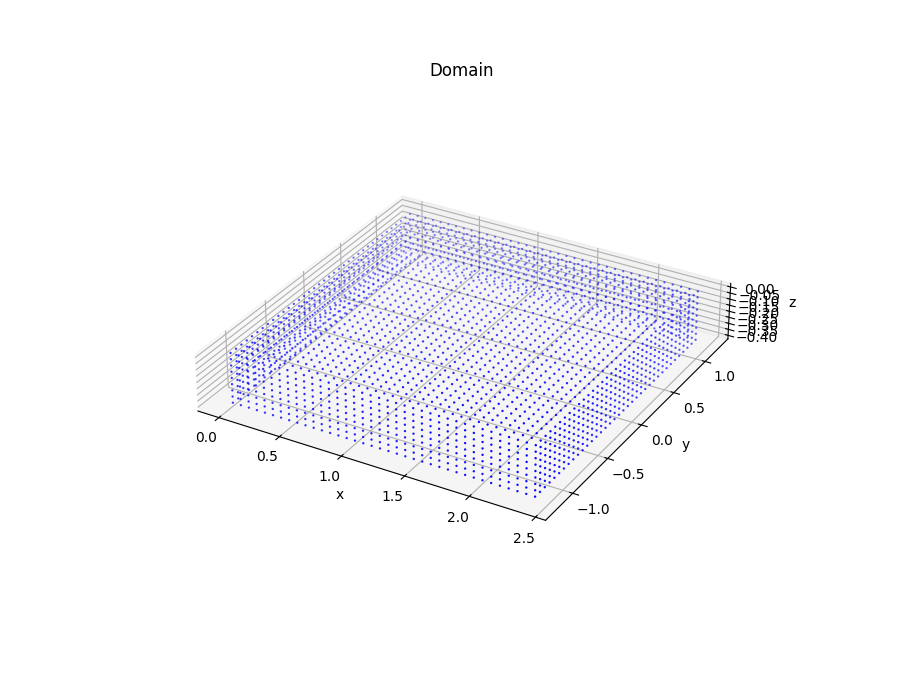

In [8]:
# Domain visulization
%matplotlib widget

fig = plt.figure(figsize=(9, 7)) # Interactive plots also respect figsize
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='b',
    s=0.5
)

# DOMAIN LIMITS
x_min, x_max = np.min(MESH_0_POS[:,0]), np.max(MESH_0_POS[:,0])
y_min, y_max = np.min(MESH_0_POS[:,1]), np.max(MESH_0_POS[:,1])
z_min, z_max = np.min(MESH_0_POS[:,2]), np.max(MESH_0_POS[:,2])

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Domain")

# Aspect ratio
ax.set_box_aspect([Lx, Ly, Lz])

# ax.set_xlim(x_min, x_max)
# ax.set_ylim(y_min, y_max)
# ax.set_zlim(z_min, z_max)

plt.show()

In [9]:
# Identify elements belonging to each boundary and compute their outward normal vectors
REF_R0 , NORMAL_0 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_0 , MESH_0_POS , NE[0], N_STRUCT)

In [10]:
# Total number of nodes (useful when extending to multi-region simulations)
N_total = N[0]

**4. Influence matrices**

In [11]:
# Form H and B matrices
H , G = GHMAT6(MESH_0_POS , NCONEC , KCONEC_0 , NE[0] , N[0] , DEPTH);

**5. Frequency loop and boundary condition application**

In [12]:
# Dictionary to store wave properties for each frequency case
WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# Frequency loop
for tt in range(ttmax):

    print(tt + 1)

    # Compute wavenumber from dimensionless kh
    k = kh[tt] / DEPTH

    # Linear wave dispersion relation → wave period
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # Wave frequency and angular frequency
    f = 1.0 / T
    omega = 2*np.pi*f

    # Wave height from steepness H/λ and corresponding amplitude
    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # Backup original system matrices before applying BCs
    A = H.copy()
    B = G.copy()

    # ------------------------
    # Apply boundary conditions
    # ------------------------

    # Free-surface boundary condition
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC_0, NE, 0)

    # Radiation boundary conditions at inlet and outlet (far field)
    A = BC_FAR_FIELD_OBLIQUE_IN(A, B, k, THETA, NCONEC, NORMAL_0, REF_R0["IN"],    KCONEC_0, NE, 0)
    A = BC_FAR_FIELD_OBLIQUE_IN(A, B, k, THETA, NCONEC, NORMAL_0, REF_R0["FRONT"], KCONEC_0, NE, 0)

    A = BC_FAR_FIELD_OBLIQUE_OUT(A, B, k, THETA, NCONEC, NORMAL_0, REF_R0["OUT"],  KCONEC_0, NE, 0)
    A = BC_FAR_FIELD_OBLIQUE_OUT(A, B, k, THETA, NCONEC, NORMAL_0, REF_R0["BACK"], KCONEC_0, NE, 0)

    # Scattering boundary condition from incident potential at inlet
    BC_S = np.zeros_like(KCONEC_0[:NCONEC, :], dtype=np.complex128)
    BC_S = BC_SCATTERING_OBLIQUE(BC_S, Wave_height, k, omega, gravity, DEPTH, THETA, MESH_0_POS, NORMAL_0, NCONEC, REF_R0["IN"],    KCONEC_0, N, NE, 0)
    BC_S = BC_SCATTERING_OBLIQUE(BC_S, Wave_height, k, omega, gravity, DEPTH, THETA, MESH_0_POS, NORMAL_0, NCONEC, REF_R0["FRONT"], KCONEC_0, N, NE, 0)

    # Build right-hand-side vector (B · BC_S)
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # Solve linear BEM system
    Coef_S = np.linalg.solve(A, FX_S)

# End of frequency loop

1


**6. Results**

**6.1 Free surface**

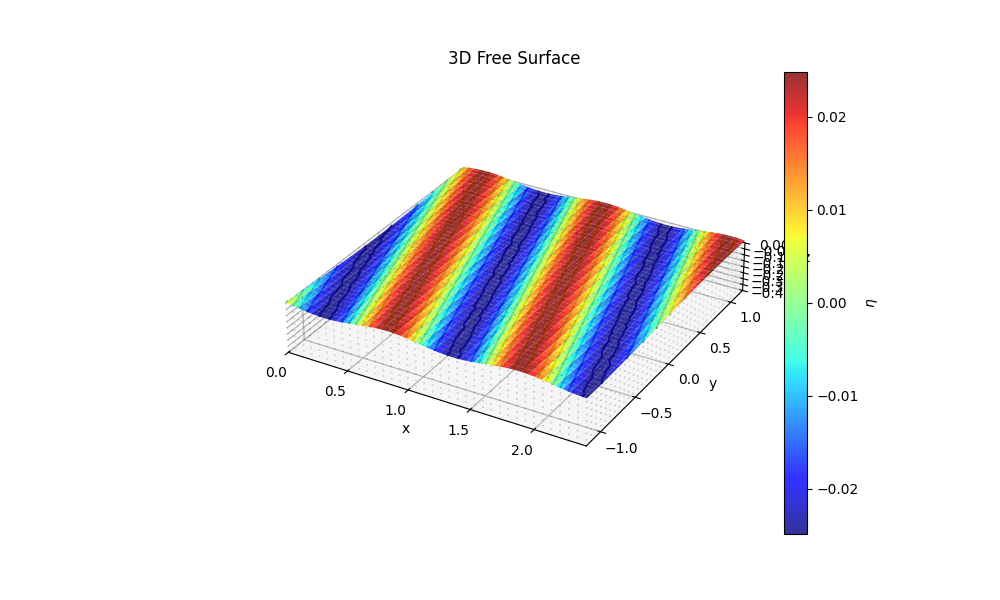

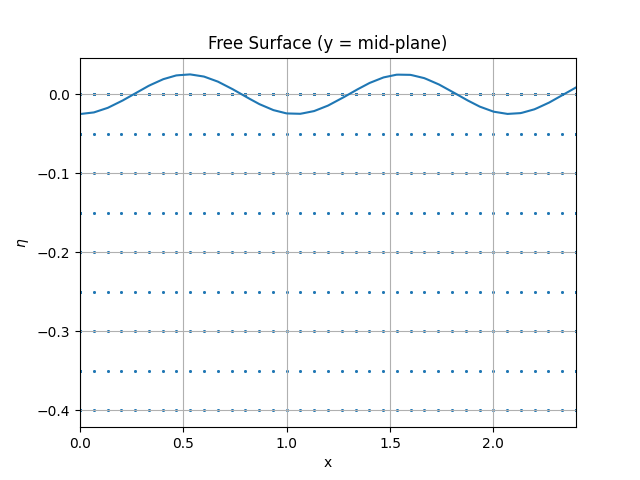

In [13]:
# Free surface plot
PHI_FS_0 = VISUAL_FREE_SURFACE(Coef_S, k, omega, gravity, Wave_height, DEPTH, NCONEC, REF_R0["FS"], MESH_0_POS, MESH_0_POS, KCONEC_0, N, NE, 0)

**6.2 Internal points**

In [14]:
# Initialize array to store flux values (dphi/dn) across all boundaries
Fluxes_S = np.zeros_like(KCONEC_0[0:NCONEC,:], dtype=np.complex128)

In [15]:
# For single domain cases Coef_S contains only velocity potentials
# For multi-domain, Coef_S will contain potentials and fluxes

# Boundary conditions
# Inlet  dPHI/dn + ik PHI = 0
# Outlet dPHI/dn - ik PHI = 0
# FS     dPHI/dn - omega^2/g PHI = 0
# Bottom dPHI/dn = 0
# Imper  dPHI/dn = 0
# Front  dPHI/dn = 0
# Back   dPHI/dn = 0

# Fluxes calculation
Fluxes_S = FLUXES_FREE_SURFACE(Coef_S, Fluxes_S, omega, gravity, NCONEC, REF_R0["FS"], KCONEC_0, N, NE, 0)
Fluxes_S = FLUXES_FAR_FIELD_OBLIQUE_IN(Coef_S, Fluxes_S, k, THETA, NCONEC, NORMAL_0, REF_R0["IN"], KCONEC_0, N, NE, 0)
Fluxes_S = FLUXES_FAR_FIELD_OBLIQUE_IN(Coef_S, Fluxes_S, k, THETA, NCONEC, NORMAL_0, REF_R0["FRONT"], KCONEC_0, N, NE, 0)

Fluxes_S = FLUXES_FAR_FIELD_OBLIQUE_OUT(Coef_S, Fluxes_S, k, THETA, NCONEC, NORMAL_0, REF_R0["OUT"], KCONEC_0, N, NE, 0)
Fluxes_S = FLUXES_FAR_FIELD_OBLIQUE_OUT(Coef_S, Fluxes_S, k, THETA, NCONEC, NORMAL_0, REF_R0["BACK"], KCONEC_0, N, NE, 0)

In [16]:
# Calculation of internal velocity potentials
Max_X0 = max(MESH_0_POS[:,0])

dx = 0.01
dz = 0.10

CX_0 = np.linspace(0 + dx, Max_X0 - dx, 301)
CY_0 = np.zeros_like(CX_0)
CZ_0 = np.zeros_like(CX_0) - dz

DSOL_0 = INTERNAL_POINTS(Coef_S, Fluxes_S, DEPTH, CX_0, CY_0, CZ_0, MESH_0_POS, NCONEC, KCONEC_0, N, NE, 0)

ETA_IP_0 = np.real((1j * rho * omega) * DSOL_0  * np.exp(-1j * omega * np.pi / omega))

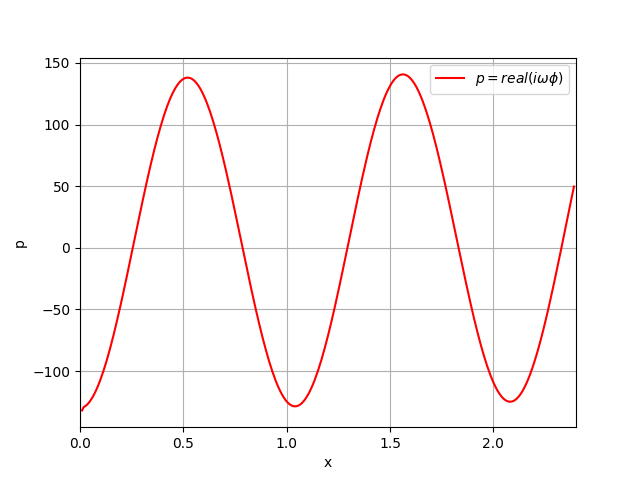

In [17]:
# Plot of the dynamic pressure amplitude
plt.figure()

plt.plot(CX_0, ETA_IP_0, 'r-', label=r'$p = real(i\omega\phi)$')

plt.xlim([0, Max_X0])

plt.xlabel('x')
plt.ylabel('p')

plt.legend()
plt.grid(True)

# Optional: display the plot
plt.show()